# Vertical Reflectivity Gradient Histograms

Computes and plots histograms of the vertical reflectivity gradient (VRG; dBZ km⁻¹) measured by Micro Rain Radars (MRR) at two sites (Alta and Highland) for three event types: S/SWIVT, Frontal, and NW Postfrontal.

A linear regression is performed on each reflectivity profile between user-specified height bounds, and the resulting slopes are binned into histograms. A companion bar chart shows the fraction of profiles excluded due to missing data at the bottom or top of the layer.

VRG is calculated as:

$$\mathrm{VRG} = \frac{\sum_{i=1}^{n} (z_i - \bar{z})(Z_{e,i} - \bar{Z}_e)}{\sum_{i=1}^{n} (z_i - \bar{z})^2}$$

**Authors:** Jim Steenburgh, Ashley Evans, Michael Wasserstein  
**Date:** June 2024



In [1]:
import os
import math
import numpy as np
import xarray as xr
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import FancyArrowPatch
from MRR_functions import open_ds

## Configuration

Set the paths and height bounds before running.

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────
# Directory containing the MRR NetCDF files (highland030_*.nc, alta180_*.nc, etc.)
data_path = 'Data/MRR/'

# Directory where figures will be saved
fig_dir = 'Fig/'

# ── Height bounds for the reflectivity-gradient calculation ─────────────
# Lowest usable range gate for the 30-m dataset is 120 m AGL;
# highest usable range gate is 900 m AGL.
min_height = 120   # m AGL
max_height = 900   # m AGL


## Load Data

In [3]:
# Load MRR data for each event type
highland180_SIVT, highland30_SIVT, alta180_SIVT, alta30_SIVT = open_ds(data_path, 'SIVT')
highland180_FR,   highland30_FR,   alta180_FR,   alta30_FR   = open_ds(data_path, 'FR')
highland180_PF,   highland30_PF,   alta180_PF,   alta30_PF   = open_ds(data_path, 'PF')

## Compute Vertical Reflectivity Gradients

Calculated as:

$$\mathrm{VRG} = \frac{\sum_{i=1}^{n} (z_i - \bar{z})(Z_{e,i} - \bar{Z}_e)}{\sum_{i=1}^{n} (z_i - \bar{z})^2}$$

In [4]:
def reflectivity_slope_histogram(ds, min_height=120, max_height=900):
    """
    Compute the vertical reflectivity gradient (slope) for each time step
    via linear regression over the specified height layer.

    Parameters
    ----------
    ds : xarray.Dataset
        MRR dataset containing 'Ze' (reflectivity) and 'height' variables.
    min_height : int
        Lower height bound of the regression layer (m AGL).
    max_height : int
        Upper height bound of the regression layer (m AGL).

    Returns
    -------
    slopes : np.ndarray
        Per-timestep regression slopes (dBZ km⁻¹); NaN where data
        are insufficient.
    count_nan : int
        Number of timesteps for which a slope could not be computed.
    min_height : int
        Lower height bound (passed through for labelling).
    max_height : int
        Upper height bound (passed through for labelling).
    list_bars : list of int
        Counts of [bottom-echo missing, both echoes missing,
        top-echo missing] used in the companion bar chart.
    """
    # Counters for missing-echo categories
    count_bottom_nan_top_not = 0
    count_bottom_not_top_nan = 0
    count_bottom_nan_top_nan = 0

    # Indices bounding the regression layer
    min_ind = np.where(ds.height.values == min_height)[0][0]
    max_ind = np.where(ds.height.values == max_height)[0][0]

     # Determine the number of times
    time_len     = ds.sizes['time']
    height_subset = ds.height.values[min_ind:max_ind + 1] / 1000  # convert m → km

    # Initialize arrays to store data
    slopes     = np.full(time_len, np.nan)
    intercepts = np.full(time_len, np.nan)
    r_values   = np.full(time_len, np.nan)

    # Loop through all the times and determine the reflectivity values for the levels of interest
    for i in range(time_len):
        refl_profile = ds.isel(time=i).Ze.values[min_ind:max_ind + 1]
        mask = ~np.isnan(refl_profile)

        # Require at least two valid points and valid data at both layer boundaries to calculate slope
        if (np.sum(mask) >= 2
                and not np.isnan(refl_profile[0])
                and not np.isnan(refl_profile[-1])):
            # Calculate VRG
            slope, intercept, r_value, _, _ = linregress(
                height_subset[mask], refl_profile[mask]
            )
            slopes[i]     = slope
            intercepts[i] = intercept
            r_values[i]   = r_value

        # Tally missing-echo categories
        bottom_nan = np.isnan(refl_profile[0])
        top_nan    = np.isnan(refl_profile[-1])
        if bottom_nan and not top_nan:     # Data not at the lowest range gate but at the top
            count_bottom_nan_top_not += 1
        elif not bottom_nan and top_nan:   # Data at the lowest range gate but not at the top
            count_bottom_not_top_nan += 1
        elif bottom_nan and top_nan:       # Data at neither the top range gate or the bottom
            count_bottom_nan_top_nan += 1

    # Bars for the plot of top or bottom not valid or both
    list_bars = [count_bottom_nan_top_not, count_bottom_nan_top_nan,
                 count_bottom_not_top_nan]

    return slopes, list_bars


In [5]:
# Compute vertical reflectivity gradients for each site and event type
reflectivity_slope_Alta_SIVT,  bars_Alta_SIVT  = reflectivity_slope_histogram(alta30_SIVT,     min_height=min_height, max_height=max_height)
reflectivity_slope_Alta_FR,    bars_Alta_FR    = reflectivity_slope_histogram(alta30_FR,       min_height=min_height, max_height=max_height)
reflectivity_slope_Alta_PF,    bars_Alta_PF   = reflectivity_slope_histogram(alta30_PF,        min_height=min_height, max_height=max_height)

reflectivity_slope_Highland_SIVT,  bars_Highland_SIVT = reflectivity_slope_histogram(highland30_SIVT, min_height=min_height, max_height=max_height)
reflectivity_slope_Highland_FR,    bars_Highland_FR   = reflectivity_slope_histogram(highland30_FR,   min_height=min_height, max_height=max_height)
reflectivity_slope_Highland_PF,    bars_Highland_PF   = reflectivity_slope_histogram(highland30_PF,   min_height=min_height, max_height=max_height)

## Plot

In [6]:
# Global plot style
matplotlib.rcParams['axes.facecolor']       = [1, 1, 1, 1]
matplotlib.rcParams['axes.edgecolor']       = 'black'
matplotlib.rcParams['axes.labelsize']       = 14
matplotlib.rcParams['axes.titlesize']       = 14
matplotlib.rcParams['xtick.labelsize']      = 12
matplotlib.rcParams['ytick.labelsize']      = 12
matplotlib.rcParams['legend.fontsize']      = 10
matplotlib.rcParams['legend.facecolor']     = 'w'
matplotlib.rcParams['legend.edgecolor']     = 'gray'
matplotlib.rcParams['savefig.transparent']  = False
matplotlib.rcParams['xtick.major.width']    = 1
matplotlib.rcParams['xtick.major.size']     = 8
matplotlib.rcParams['ytick.major.width']    = 1
matplotlib.rcParams['ytick.major.size']     = 8

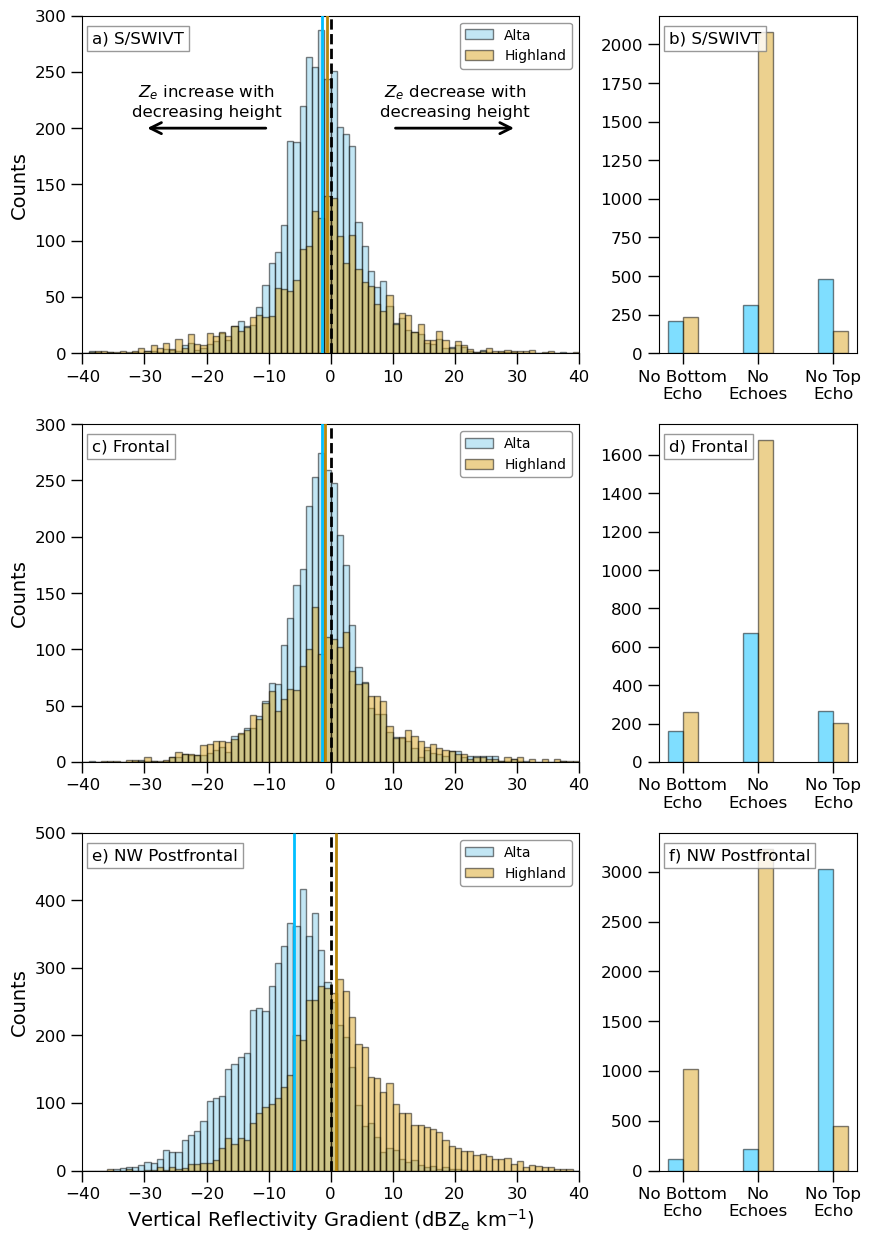

In [ ]:
# Helper variables
bins    = np.arange(-0.05, 0.06, 0.001) * 1000   # dBZ km⁻¹
dens    = False                                    # density=False → raw counts
fs      = 12                                       # annotation font size
x_pos   = [50, 60, 70]                            # x positions for bar chart
bar_w   = 2                                        # bar width

# Create figure and axis
fig, ((ax1, ax1_), (ax2, ax2_), (ax3, ax3_)) = plt.subplots(
    3, 2, facecolor='white', edgecolor='k', sharex=False,
    figsize=(10, 15), gridspec_kw={'width_ratios': [2.5, 1]}
)


# 
def _hist_panel(ax, slope_alta, slope_highland, label):
    """Plot overlapping histograms with median lines for one event type."""
    # Plot the histogram
    n_a, _, _ = ax.hist(slope_alta,     color='skyblue',   alpha=0.5,
                        bins=bins, label='Alta',     edgecolor='k', density=dens)
    n_h, _, _ = ax.hist(slope_highland, color='goldenrod', alpha=0.5,
                        bins=bins, label='Highland', edgecolor='k', density=dens)
    rounded_up = math.ceil(np.max([n_a, n_h]) / 100) * 100   # Use this to help set the y limit

    # Add median lines
    ax.vlines(np.nanmedian(slope_alta),     0, 500, colors='deepskyblue',  linewidth=2, zorder=19)
    ax.vlines(np.nanmedian(slope_highland), 0, 500, colors='darkgoldenrod', linewidth=2, zorder=19)

    # Add zero line
    ax.vlines(0, 0, 500, colors='black', linewidth=2, linestyle='--', zorder=500)

    # Add limits, labels, ticks, and legend
    ax.set_xlim(-40, 40)
    ax.set_ylim(0, rounded_up)
    ax.set_xticks(np.arange(-40, 41, 10))
    ax.set_ylabel('Counts', fontsize=14)
    ax.legend()
    return rounded_up


def _bar_panel(ax_, bars_alta, bars_highland):
    """Plot the companion missing-echo bar chart."""
    ax_.bar(np.array(x_pos) - 1, bars_alta,     width=bar_w, color='deepskyblue', edgecolor='k', alpha=0.5)
    ax_.bar(np.array(x_pos) + 1, bars_highland, width=bar_w, color='goldenrod',   edgecolor='k', alpha=0.5)
    ax_.set_xticks(x_pos, labels=['No Bottom\nEcho', 'No\nEchoes', 'No Top\nEcho'], rotation=0)


# ── S/SWIVT ──────────────────────────────────────────────────────────────────
_hist_panel(ax1, reflectivity_slope_Alta_SIVT, reflectivity_slope_Highland_SIVT, 'S/SWIVT')
_bar_panel(ax1_, bars_Alta_SIVT, bars_Highland_SIVT)

# ── Frontal ───────────────────────────────────────────────────────────────────
_hist_panel(ax2, reflectivity_slope_Alta_FR, reflectivity_slope_Highland_FR, 'Frontal')
_bar_panel(ax2_, bars_Alta_FR, bars_Highland_FR)

# ── NW Postfrontal ────────────────────────────────────────────────────────────
_hist_panel(ax3, reflectivity_slope_Alta_PF, reflectivity_slope_Highland_PF, 'NW Postfrontal')
_bar_panel(ax3_, bars_Alta_PF, bars_Highland_PF)

ax3.set_xlabel(r'Vertical Reflectivity Gradient (dBZ$\mathrm{_{e}}$ km$^{-1}$)', fontsize=14)

# ── Panel labels ──────────────────────────────────────────────────────────────
props = dict(boxstyle='square', facecolor='white', alpha=0.8, ec='gray')
for ax, label in [
    (ax1,  'a) S/SWIVT'),       (ax1_, 'b) S/SWIVT'),
    (ax2,  'c) Frontal'),        (ax2_, 'd) Frontal'),
    (ax3,  'e) NW Postfrontal'), (ax3_, 'f) NW Postfrontal'),
]:
    x_off = 0.02 if ax in (ax1, ax2, ax3) else 0.05
    ax.text(x_off, 0.92, label, transform=ax.transAxes, fontsize=fs, bbox=props)

# ── Annotation arrows and labels on S/SWIVT panel ────────────────────────────
ax1.text(0.75, 0.80, '$Z_e$ decrease with\ndecreasing height',
         transform=ax1.transAxes, fontsize=fs, ha='center', va='top')
ax1.text(0.25, 0.80, '$Z_e$ increase with\ndecreasing height',
         transform=ax1.transAxes, fontsize=fs, ha='center', va='top')
for x_start, x_end in [(10, 30), (-10, -30)]:
    ax1.add_patch(FancyArrowPatch(
        posA=(x_start, 200), posB=(x_end, 200),
        arrowstyle='->', mutation_scale=20, lw=2, color='k'
    ))

# Adjust figure, save, and show
plt.subplots_adjust(hspace=0.21, wspace=0.23)
plt.savefig(os.path.join(fig_dir, f'VRG_hist_min{min_height}_max{max_height}.png'),
            bbox_inches='tight', dpi=300)
plt.show()
